In [1]:
import mlflow
import pandas as pd
import numpy as np
import torch
import joblib


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


from torch.utils.data import TensorDataset, DataLoader, random_split
from torch import nn
from torchmetrics import MetricCollection, MeanSquaredError, MeanAbsoluteError, R2Score

import torch.optim as optim



In [2]:
mlflow.set_tracking_uri("sqlite:///db/mlflow.db")

# MlFLow Models

- Used for packaging models
    - Flavours:
    - 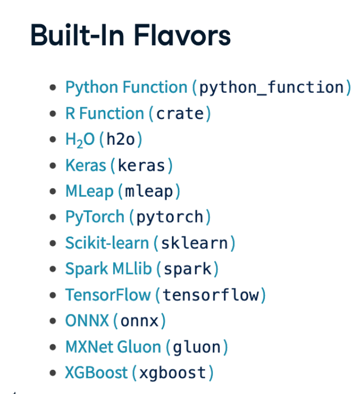

` import mlflow.FLAVOR `

# Autolog

```
import mlflow.FLAVOR.autolog()

ex: mlflow.sklearn.autolog()
```

### Metrics and Parameters Logged with Autolog



# Example usage of Sci-Kit Learn Flavor

```
import mlflow
from sklearn.lieanr_model import LinearRegresion

#activate auto-logging
mlflow.sklearn.autolog()

# Train model
lr = LinearRegression()
lr.fit(X,y) #logging happens automatically

```

when `model.fit()` is called, model will be automatically logged

In [3]:
diabetes_df = pd.read_csv("../scikit-learn/data/diabetes_clean.csv")
X = diabetes_df.drop(columns=["diabetes"])
y = diabetes_df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [4]:
mlflow.sklearn.autolog()

lr = LinearRegression()
lr.fit(X_train, y_train)



2026/07/04 00:39:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/04 00:39:50 INFO mlflow.store.db.utils: Updating database tables
2026/07/04 00:39:50 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f966d68124424ea29e8c105df634ef48', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 00:39:50 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/homebrew/anaconda3/envs/hands_on_ml/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) tha

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Storage format of an model
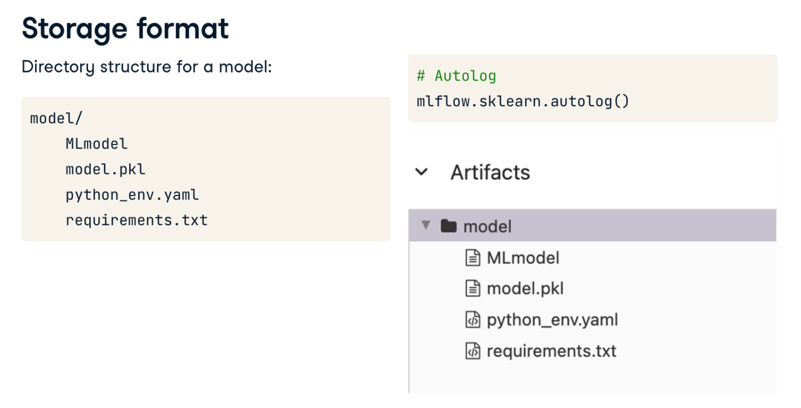

*MLModel file is a yaml file


# MLflow REST API

# Saving  Model

```
# Save a model to the local filesystem
mlflow.sklearn.save_model(model, path)

# Log a model as an artifact to MLflow Tracking.
mlflow.sklearn.log_model(model, artifact_path) #artifact_path is generally model, name of the artifact

# Load a model from local filesystem or from MLflow Tracking.
mlflow.sklearn.load_model(model_uri)
```

FAZIT: log_model is more advanced

Save_model just writes the model to a folder somewhere on disk. It's an isolated file operation, completely disconnected from MLflow's tracking system. There's no context attached, **no info about which run produced it, what hyperparameters were used**, what metrics it achieved. Just a model file sitting in a path.

**log_model, on the other hand, embeds the model inside a run, alongside everything else that run tracked** (parameters, metrics, tags). It gets written through the tracking server into that run's artifact store (which could be local disk, S3, Azure Blob, wherever it's configured), organized under an artifact_path.

The practical payoff shows up here: say you train 50 different hyperparameter combinations, each logged as a separate run. **If you use log_model, opening any run in the MLflow UI shows you that run's model right next to its metrics (RMSE, R², whatever). Once you find the run with the best metric, you grab its model_uri (something like runs:/<run_id>/model) and load it back directly with load_model,** without ever needing to know the actual file path.

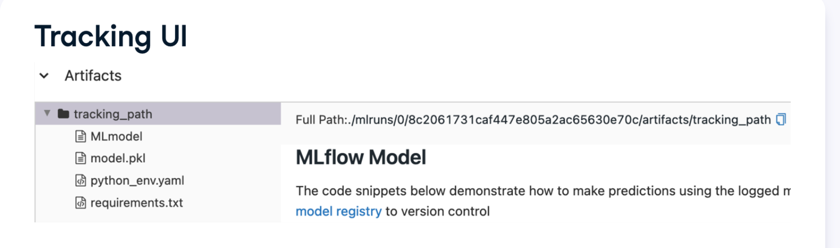

### Model URI for loading back:
```
Local Filesystem - relative/path/to/local/model or /Users/me/path/to/local/model

MLflow Tracking - runs:/<mlflow_run_id>/run-relative/path/to/model

S3 Support - s3://my_bucket/path/to/model

```







# Saving Imputers/Pipeline as Artifact to Model


## Method 1 : with sklearn.log_model()
* Works if the imputer is sklearn-compatible (inherits BaseEstimator, TransformerMixin).

* **should be be already fitted with train_data, unless doesnt make sense** (not sure)

```
import mlflow.sklearn

with mlflow.start_run():
    imputer.fit(X_train)
    mlflow.sklearn.log_model(imputer, "imputer")
```

```
from sklearn.pipeline import Pipeline

preprocessor = Pipeline([
    ("imputer", imputer),
    ("encoder", encoder),
    ("scaler", scaler),
])
preprocessor.fit(X_train)

with mlflow.start_run():
    mlflow.sklearn.log_model(preprocessor, "preprocessor")
```

loading:

```
loaded_preprocessor = mlflow.sklearn.load_model("runs:/<run_id>/preprocessor")
```

## Method 2 :  log_artifact + joblib/pickle

* saving as pickle:

```
import joblib

preprocessor = Pipeline([
    ("imputer", imputer),
    ("encoder", encoder),
    ("scaler", scaler),
])
preprocessor.fit(X_train)

joblib.dump(preprocessor, "preprocessor.pkl")

```

* uploading to mlflow:
```
with mlflow.start_run():
    mlflow.log_artifact("imputer.pkl", artifact_path="preprocessing")
```

* loading back from mlflow.artifact and opening
```
 local_path = mlflow.artifacts.download_artifacts(
    run_id="<run_id>", artifact_path="preprocessing/preprocessor.pkl")

with open(local_path, "rb") as f:
    imputer = pickle.load(f)
```

In [5]:
mlflow.sklearn.log_model(lr,"model")

2026/07/04 00:39:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/04 00:39:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


# Workflow: Recieving Last Run ID and Loading the Model From There

```
# Get last active run
run = mlflow.last_active_run()
# Set run_id variable
run_id = run.info.run_id
# Pass run_id as f-string literal
model = mlflow.sklearn.load_model(f"runs:/{run_id}/tracking_path")
# tracking_path is what we set, here model
```

In [6]:
# Get last active run
run = mlflow.last_active_run()
run

<Run: data=<RunData: metrics={'training_mean_absolute_error': 0.3320970464812352,
 'training_mean_squared_error': 0.15744485172625472,
 'training_r2_score': 0.30506972801106247,
 'training_root_mean_squared_error': 0.3967932102824527,
 'training_score': 0.30506972801106247}, params={'copy_X': 'True',
 'fit_intercept': 'True',
 'n_jobs': 'None',
 'positive': 'False',
 'tol': '1e-06'}, tags={'estimator_class': 'sklearn.linear_model._base.LinearRegression',
 'estimator_name': 'LinearRegression',
 'mlflow.autologging': 'sklearn',
 'mlflow.runName': 'exultant-mink-55',
 'mlflow.source.name': '/opt/homebrew/anaconda3/envs/hands_on_ml/lib/python3.13/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'NOTEBOOK',
 'mlflow.user': 'kaan'}>, info=<RunInfo: artifact_uri=('/Users/kaan/Developer/financial '
 'python/ML/MLFlow/mlruns/0/f966d68124424ea29e8c105df634ef48/artifacts'), end_time=1783118392691, experiment_id='0', lifecycle_stage='active', run_id='f966d68124424ea29e8c105df634ef48', 

In [7]:
# Set run_id variable
run_id = run.info.run_id
run_id

'f966d68124424ea29e8c105df634ef48'

In [8]:
loaded_model =  mlflow.sklearn.load_model(f"runs:/{run_id}/model")
loaded_model.predict(X_test)


array([ 0.33550028,  0.23809869,  0.1510522 ,  0.2401365 ,  0.48142376,
        0.45257375, -0.17450469,  0.60662287,  0.52417796,  0.70476953,
        0.32360466,  0.85290601,  0.38466612,  0.36056948,  0.09946712,
        0.41539557,  0.17869123,  0.07782301,  0.80730861,  0.51299477,
        0.28090594,  0.08303057,  0.5099157 ,  0.11381771,  0.51325022,
        0.82528549,  0.17892718, -0.0594202 ,  0.28338572,  0.16407949,
        0.83851225,  0.80737515,  0.68154389,  0.7649502 ,  0.56140297,
        0.62123131,  1.06134554,  0.30990775,  0.51752336,  0.63691482,
        0.07075333,  0.57757007,  0.55015462,  0.37541745, -0.07644182,
        0.50119208,  0.59600162,  0.27464761,  0.42477995,  0.9941898 ,
        0.00969584,  0.61763578,  0.73395288,  0.31090975,  0.13456812,
       -0.02536316,  0.71219147, -0.30518218,  0.41994556,  0.67869594,
        0.66891428,  0.3798452 ,  0.2956646 ,  0.288035  ,  0.06813053,
        0.55464338,  0.01368504,  0.6272007 , -0.02033281,  0.63

# PyTorch Flavor

### Basic API

```python
import mlflow.pytorch

# Save
mlflow.pytorch.save_model(pytorch_model, path)

# Log
mlflow.pytorch.log_model(pytorch_model, artifact_path)

# Load (as a native PyTorch model, not .predict() but forward pass)
model = mlflow.pytorch.load_model(model_uri)
```

Key difference from other flavors: `load_model()` returns the original `torch.nn.Module` directly (default behavior), not a `pyfunc`-wrapped object. So you can keep using normal PyTorch calls like `model.eval()`, `model(input_tensor)`.

### Two loading modes

- `mlflow.pytorch.load_model()` → returns the raw `torch.nn.Module`, you keep using the PyTorch API (`.forward()`, `.eval()`, `.to(device)`, etc).
- `mlflow.pyfunc.load_model()` → wraps the same model URI with the generic pyfunc interface, called via `.predict(pandas_df_or_numpy_array)`. This is the mode used automatically when serving via `mlflow models serve`, since the serving layer expects the flavor-agnostic `pyfunc` interface.

### Autologging

```python
mlflow.pytorch.autolog()
```

*Call this before your training loop and MLflow automatically logs epoch-level loss/metrics, optimizer params, and checkpoints, no manual `mlflow.log_metric()` needed.

**However, it's mainly designed to integrate with `pytorch_lightning.Trainer`.**
    *For a raw PyTorch loop (like your manual `for epoch in range(...)` on Ames Housing), autolog's coverage is limited, **so manual logging (`mlflow.log_metric("train_loss", loss.item(), step=epoch)`) is usually the more controlled approach.**



### State dict vs. full model

The flavor uses PyTorch's own serialization (`torch.save`) and, by default, pickles the entire model (architecture + weights), not just the `state_dict`. This mirrors the convenience of sklearn's `save_model`: you don't need to re-import the model class, `load_model()` gives you a working object directly. The tradeoff is slightly more fragility across Python/PyTorch version mismatches compared to `state_dict`-based storage.

### Logging Model


```python
mlflow.pytorch.log_model(
    pytorch_model=model,
    artifact_path="model",
    registered_model_name="ames_housing_nn"  # optionally registers it too
)
```

### registered_model_name is about mlflow model registry and handled in another notebook

# Manuel Logging with TorchMetrics

* Adding prefix to MetricCollection helps differeantiating betwen training and validation losses:

```
train_metrics = MetricCollection({
    "mse": MeanSquaredError(),
    "mae": MeanAbsoluteError(),
    "r2": R2Score(),
}, prefix="train_")

train_metrics = MetricCollection({
    "mse": MeanSquaredError(),
    "mae": MeanAbsoluteError(),
    "r2": R2Score(),
}, prefix="train_")


```

* inside the loop/ at the end of the loop:


```

train_metrics.update(preds, targets)2
train_results = train_metrics.compute()  # dict[str, Tensor],  {"train_mse": ..., "train_mae": ..., "train_r2": ...}

mlflow.log_metrics(
            {f"train_{k}": v.item() for k, v in results.items()}, #.item turns tensor to scalar
            step=epoch #step epoch to log the metric of current epoch
        )

metric_collection.reset()
```


In [9]:

dataset = TensorDataset(torch.tensor(X.to_numpy(), dtype=torch.float32), torch.tensor(y.to_numpy(), dtype=torch.float32))

total = len(dataset)

n_train = int(0.7 * total)
n_val = int(0.15 * total)

n_test = total - n_train - n_val

batch_size = 32

train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])

# Creating 3 different loaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

In [10]:
model_mlflow = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1)
)

optimizer = optim.Adam(model_mlflow.parameters(), lr= 0.001)
criterion = nn.MSELoss()


# Training Loop With MLFLOW and Torchmetrics

In [11]:
num_epochs = 100

train_metrics = MetricCollection({
    "mse": MeanSquaredError(),
    "mae": MeanAbsoluteError(),
    "r2": R2Score(),
}, prefix="train_")

val_metrics = MetricCollection({
    "mse": MeanSquaredError(),
    "mae": MeanAbsoluteError(),
    "r2": R2Score(),
}, prefix="val_")


# FLOW1: at start before for, context manager with ml_flow.start run. run has multiple epochs
with mlflow.start_run():

    #FLOW2: logging optimizer and learning rate decision
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 0.001)


    for epoch in range(num_epochs):

        # ---- Train ----
        model_mlflow.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model_mlflow(X_batch).squeeze()
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            #METRIC1: Updating metrics inside train_loader for batch
            train_metrics.update(preds, y_batch)

        #METRIC2: At the end of epoch, with compute the loss is calculated
        train_results = train_metrics.compute()

        #FLOW3: with log_metrics the calculated losses are logged
        mlflow.log_metrics(
            {f"train_{k}": v.item() for k, v in train_results.items()},
            step=epoch
        )

        #METRIC3: Metrics are deleted
        train_metrics.reset()


        # ---- Validation ----
        model_mlflow.eval()
        with torch.no_grad():
            for X_val, y_val in val_loader:
                val_preds = model_mlflow(X_val).squeeze()
                val_metrics.update(val_preds, y_val)

        #SAME LOGIC
        val_results = val_metrics.compute()

        #SAME LOGIC
        mlflow.log_metrics(
            {f"val_{k}": v.item() for k, v in val_results.items()},
            step=epoch
        )
        val_metrics.reset()

        print(f"Epoch {epoch}: train_mse={train_results['train_mse']:.4f}, val_mse={val_results['val_mse']:.4f}")

    #FLOW4: TRAINED MODEL IS LOGGED WITH PYTORCH FLAVOR
    mlflow.pytorch.log_model(model_mlflow, "model")

Epoch 0: train_mse=32.1785, val_mse=0.6151
Epoch 1: train_mse=19.5559, val_mse=0.4201
Epoch 2: train_mse=8.5662, val_mse=0.4816
Epoch 3: train_mse=7.4302, val_mse=0.6955
Epoch 4: train_mse=4.5864, val_mse=0.3105
Epoch 5: train_mse=2.8543, val_mse=0.3484
Epoch 6: train_mse=3.1594, val_mse=0.3916
Epoch 7: train_mse=3.4744, val_mse=0.4388
Epoch 8: train_mse=2.5911, val_mse=0.3189
Epoch 9: train_mse=2.3724, val_mse=0.4653
Epoch 10: train_mse=1.5994, val_mse=0.3923
Epoch 11: train_mse=1.1483, val_mse=0.3370
Epoch 12: train_mse=0.9467, val_mse=0.3033
Epoch 13: train_mse=0.8575, val_mse=0.3083
Epoch 14: train_mse=0.7807, val_mse=0.3105
Epoch 15: train_mse=1.2751, val_mse=0.3112
Epoch 16: train_mse=0.8316, val_mse=0.2848
Epoch 17: train_mse=0.6709, val_mse=0.2823
Epoch 18: train_mse=0.8250, val_mse=0.2838
Epoch 19: train_mse=0.6951, val_mse=0.2918
Epoch 20: train_mse=0.7365, val_mse=0.3059
Epoch 21: train_mse=0.5756, val_mse=0.2949
Epoch 22: train_mse=0.5688, val_mse=0.2886
Epoch 23: train_mse

2026/07/04 00:39:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/04 00:39:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch 84: train_mse=0.2402, val_mse=0.2083
Epoch 85: train_mse=0.2333, val_mse=0.2077
Epoch 86: train_mse=0.2317, val_mse=0.2043
Epoch 87: train_mse=0.2245, val_mse=0.2010
Epoch 88: train_mse=0.2311, val_mse=0.2069
Epoch 89: train_mse=0.2236, val_mse=0.1993
Epoch 90: train_mse=0.2296, val_mse=0.2065
Epoch 91: train_mse=0.2648, val_mse=0.2035
Epoch 92: train_mse=0.2293, val_mse=0.1983
Epoch 93: train_mse=0.2596, val_mse=0.2060
Epoch 94: train_mse=0.2444, val_mse=0.2083
Epoch 95: train_mse=0.2787, val_mse=0.1998
Epoch 96: train_mse=0.2234, val_mse=0.2004
Epoch 97: train_mse=0.2267, val_mse=0.2067
Epoch 98: train_mse=0.2341, val_mse=0.2096
Epoch 99: train_mse=0.2218, val_mse=0.1891


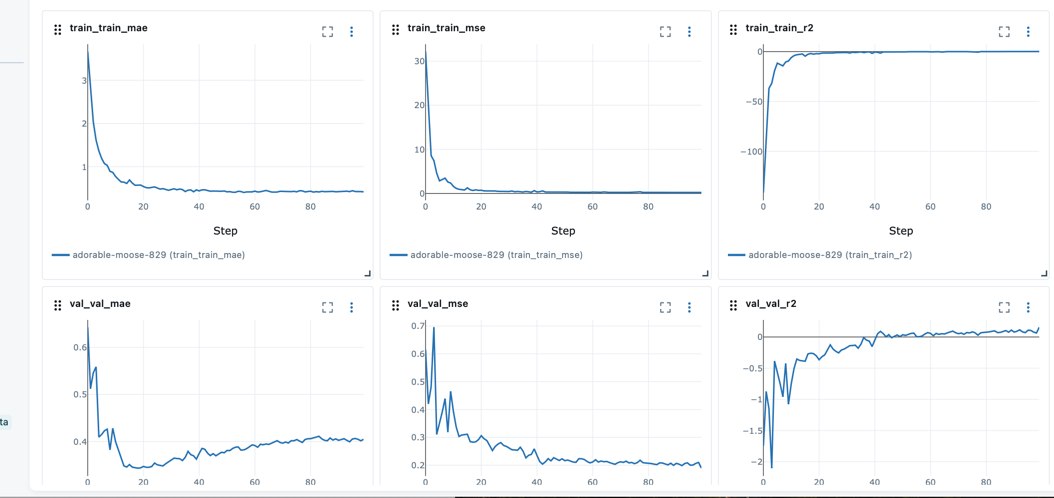

# Python_function for non defined flavors or additional logic:

Example Class:


model class is a subclass of mlflow.pyfunc.PythonModel

#### what to implement inside the class?

* load_context(self, context):
    * loading neccesary functions/models for predict to function


* predict: the real prediction step


### logging and saving model


```


mlflow.pyfunc.log_model(
    artifact_path="ames_custom_model",
    python_model=CustomPredict(), #name of the class
    artifacts={"nn_model": "runs:/{}/nn_model".format(run_id)}
)


mlflow.pyfunc.save_model(
    #same parameters
)
```

* Defining artifacts there (adding imputer and nn_model) is going to help for our functionality later

```
model = mlflow.pyfunc.load_model(f"runs:/{run_id}/ames_custom_model")
```

#### loading using the model:

use the defined ``model.predict`` for predictions

In [12]:

import mlflow.pyfunc

class CustomPredict(mlflow.pyfunc.PythonModel):

    def load_context(self, context):

        # context : it containts .artifacts

        #loads imputer function
        self.imputer = joblib.load(context.artifacts["imputer"])

        #loads any model from, we assume its saved under the artifact nn_model
        self.model = mlflow.pytorch.load_model(context.artifacts["nn_model"])

        # we switch to the evaluation mode at pytorch
        self.model.eval()

    def predict(self, context, model_input, params=None):


        # 1. Calling imputer on the model_input
        imputed = self.imputer.transform(model_input)

        # 2. PyTorch forward pass
        with torch.no_grad():
            tensor_input = torch.tensor(imputed, dtype=torch.float32)
            log_pred = self.model(tensor_input).numpy()

        # 3. Postprocessing
        return np.expm1(log_pred)




/opt/homebrew/anaconda3/envs/hands_on_ml/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


# Model Evaluation and SHAP

mlflow.evaluate() is a one-call way to get a full evaluation report **on a trained model**,without you manually computing each metric yourself.

You pass it a model reference (here a runs:/ URI pointing at the model you already logged), an evaluation dataset, which column holds the ground truth (targets="test_label"), and the model type ("regressor" or "classifier").

The output isn't just numbers. It logs a whole artifact folder back into the run: the model files (MLmodel, model.pkl, conda.yaml, etc.) plus, notably, SHAP explainability plots (beeswarm, feature importance, summary) generated automatically.

In [17]:
# Training Data
X_train, X_test, y_train, y_test = \
    train_test_split(X, y,
    train_size=0.7,random_state=0)

# Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Dataset
eval_data = X_test
eval_data["test_label"] = y_test

# It must be called with an logged model, either logged on a run or
# through a model registry "models:/ames_housing_full_pipeline/Production",


run_id = "21337f8dd4df49cd90f6001595a99a48"

mlflow.evaluate(
    f"runs:/{run_id}/model",
    eval_data,
    targets="test_label",
    model_type="regressor"
)

2026/07/04 01:04:48 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '50ccf8caabf548b7b1c8cff540a09e63', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 01:04:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/homebrew/anaconda3/envs/hands_on_ml/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integer

MlflowException: The model argument must be a string URI referring to an MLflow model, an MLflow Deployments endpoint URI, an instance of `mlflow.pyfunc.PyFuncModel`, a function, or None.

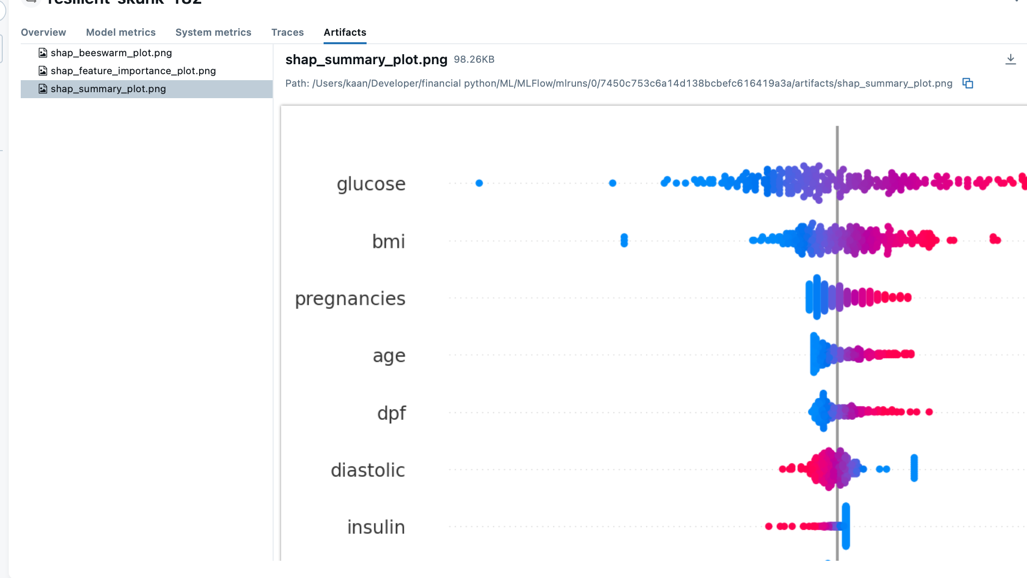
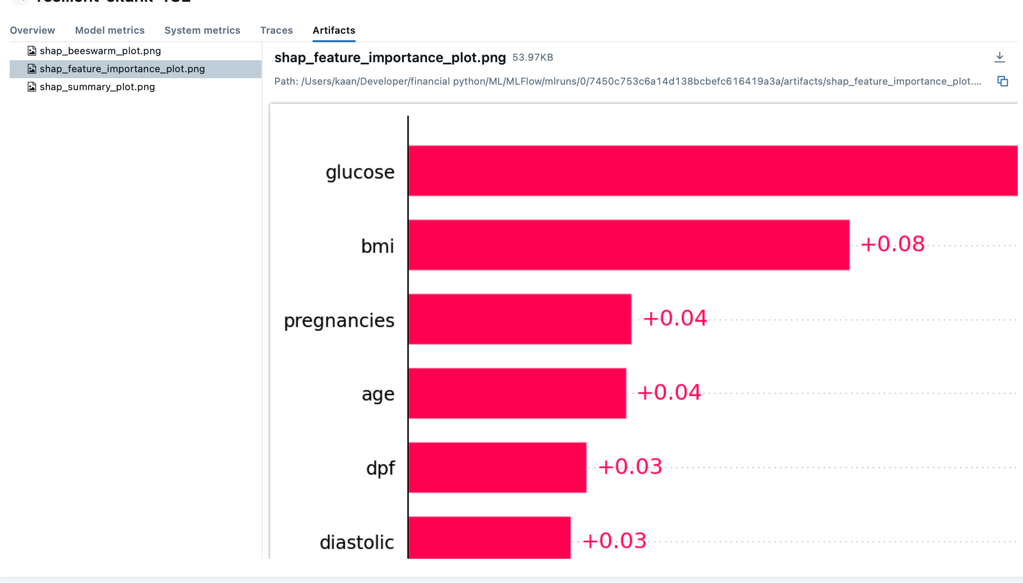